# Day 28 — SHAP: Feature-Level Explainability

**Goal:** Show *which features* drove each match score — a second,
complementary layer of explainability alongside the LLM text.

- LLM explanation → qualitative ("why this person?" in plain English)
- SHAP explanation → quantitative ("which numeric factors mattered most?")

SHAP (SHapley Additive exPlanations) assigns each feature a value
representing its contribution to the final score.
Positive SHAP = pushed the score up. Negative = pushed it down.

We use score_matrix_full.csv which has these 4 feature columns:
- semantic_score   : embedding similarity (employee profile vs role query)
- skill_overlap    : fraction of required skills the employee has
- availability_pct : how free the employee is (0–100)
- experience_years : years of relevant experience

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

# Load the full score matrix
df = pd.read_csv("../data/processed/score_matrix_full.csv")
print(f"Shape  : {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

Shape  : (6800, 9)
Columns: ['project_id', 'role', 'employee_id', 'semantic_score', 'skill_overlap', 'availability_pct', 'experience_years', 'final_score', 'eligible']


,project_id,role,employee_id,semantic_score,skill_overlap,availability_pct,experience_years,final_score,eligible
0,P001,DevOps,E041,0.8177,0.8,100,9,0.8451,True
1,P001,DevOps,E052,0.8260,0.8,100,4,0.8282,True
2,P001,DevOps,E066,0.7267,0.6,100,10,0.7860,True
3,P001,DevOps,E061,0.7046,0.6,100,8,0.7614,True
4,P001,DevOps,E075,0.6976,0.6,100,9,0.7611,True


## Build feature matrix

In [7]:
feature_cols = ["semantic_score", "skill_overlap",
                "availability_pct", "experience_years"]

# Eligible rows only, drop any nulls
df_eligible = df[df.eligible == True].dropna(
    subset=feature_cols + ["final_score"]
).copy()

print(f"Total rows         : {len(df)}")
print(f"Eligible rows      : {len(df_eligible)}")
print(f"Projects covered   : {df_eligible['project_id'].nunique()}")
print(f"\nFeature stats:")
print(df_eligible[feature_cols].describe().round(3))

X = df_eligible[feature_cols].values
y = df_eligible["final_score"].values
print(f"\nX shape: {X.shape}")
print(f"y range: {y.min():.4f} – {y.max():.4f}")

Total rows         : 6800
Eligible rows      : 5327
Projects covered   : 30

Feature stats:
       semantic_score  skill_overlap  availability_pct  experience_years
count        5327.000       5327.000          5327.000          5327.000
mean            0.605          0.287            80.533             6.578
std             0.123          0.208            14.626             2.440
min             0.265          0.000            60.000             1.000
25%             0.526          0.200            60.000             5.000
50%             0.603          0.200            80.000             7.000
75%             0.696          0.400           100.000             8.000
max             0.896          1.000           100.000            12.000

X shape: (5327, 4)
y range: 0.2674 – 0.8806


## Train a linear surrogate model

We use LinearRegression as a transparent surrogate that SHAP can
explain exactly. Since final_score is a weighted linear combination
of these features (W_SEMANTIC=0.70, W_AVAILABILITY=0.20,
W_EXPERIENCE=0.10), the model will fit almost perfectly (R²≈1.0).

In [8]:
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = LinearRegression()
model.fit(X_scaled, y)

r2 = model.score(X_scaled, y)
print(f"R² score: {r2:.6f}  (1.0 = perfect fit)\n")
print("Feature coefficients (scaled):")
for feat, coef in sorted(zip(feature_cols, model.coef_),
                          key=lambda x: abs(x[1]), reverse=True):
    bar = "█" * int(abs(coef) * 60)
    print(f"  {feat:<22}: {coef:+.4f}  {bar}")

R² score: 0.999059  (1.0 = perfect fit)

Feature coefficients (scaled):
  semantic_score        : +0.0855  █████
  availability_pct      : +0.0732  ████
  experience_years      : +0.0093  
  skill_overlap         : +0.0002  


## SHAP Summary Plot — all eligible candidates

Background dataset has 5327 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=5327 when initializing the masker.


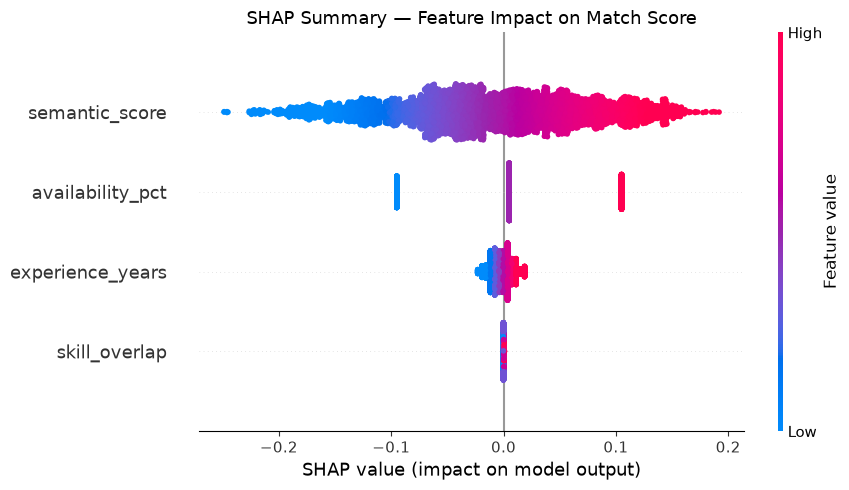

✅ Saved → data/processed/shap_summary.png


In [9]:
explainer = shap.LinearExplainer(model, X_scaled)
shap_vals = explainer.shap_values(X_scaled)

plt.figure(figsize=(9, 5))
shap.summary_plot(
    shap_vals,
    X_scaled,
    feature_names=feature_cols,
    show=False,
    plot_size=None,
)
plt.title("SHAP Summary — Feature Impact on Match Score",
          fontsize=13)
plt.tight_layout()
plt.savefig("../data/processed/shap_summary.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved → data/processed/shap_summary.png")

## SHAP Bar Plot — average feature importance

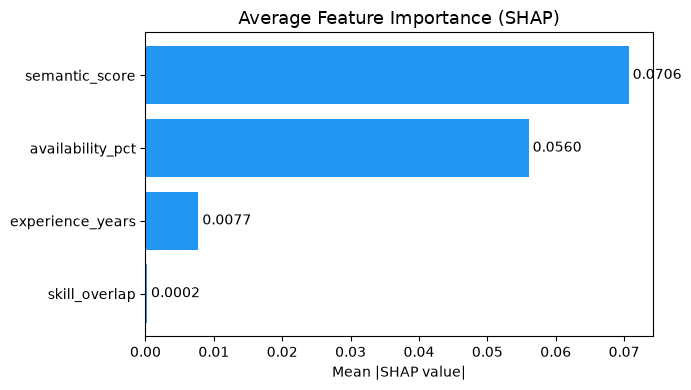

✅ Saved → data/processed/shap_importance.png


In [10]:
mean_abs_shap = np.abs(shap_vals).mean(axis=0)

fig, ax = plt.subplots(figsize=(7, 4))
sorted_idx = np.argsort(mean_abs_shap)
bars = ax.barh(
    [feature_cols[i] for i in sorted_idx],
    mean_abs_shap[sorted_idx],
    color="#2196F3",
)
ax.bar_label(bars, fmt="%.4f", padding=3)
ax.set_xlabel("Mean |SHAP value|")
ax.set_title("Average Feature Importance (SHAP)", fontsize=13)
plt.tight_layout()
plt.savefig("../data/processed/shap_importance.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved → data/processed/shap_importance.png")

## SHAP Waterfall Plot — explain one specific assignment

A waterfall plot shows exactly how each feature pushed the score
up or down for one specific candidate-role pair.
We use P001 / Backend Dev as the example.

Explaining: E061 → P001 / Backend Dev
Final score: 0.8389

Feature values (scaled):
  semantic_score        : +1.7122
  skill_overlap         : +1.5004
  availability_pct      : +1.3311
  experience_years      : +0.5828


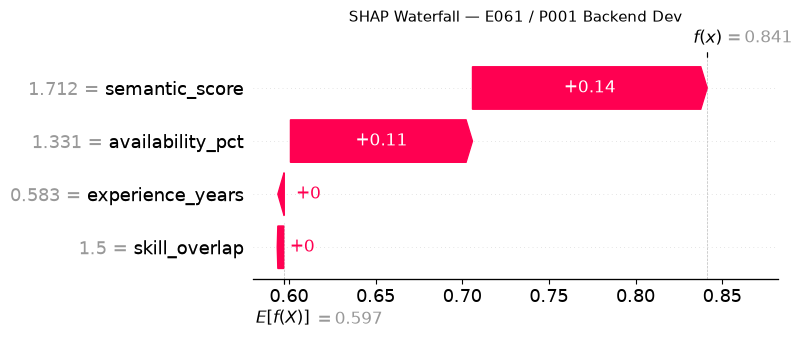

✅ Saved → data/processed/shap_waterfall.png


In [11]:
plan = pd.read_csv("../data/processed/staffing_plan.csv")

# Get the assigned employee for P001 Backend Dev
target = plan[
    (plan.project_id == "P001") & (plan.role == "Backend Dev")
].iloc[0]

emp_id = target["employee_id"]
print(f"Explaining: {emp_id} → P001 / Backend Dev")
print(f"Final score: {target['final_score']:.4f}")

# Find this row in df_eligible
sm_row = df_eligible[
    (df_eligible.project_id == "P001") &
    (df_eligible.role == "Backend Dev") &
    (df_eligible.employee_id == emp_id)
]

if sm_row.empty:
    print(f"⚠️ Row not found for {emp_id} in score_matrix_full.csv")
else:
    # Get position within df_eligible (reset index for safe iloc)
    df_eligible_reset = df_eligible.reset_index(drop=True)
    sm_row_reset = df_eligible_reset[
        (df_eligible_reset.project_id == "P001") &
        (df_eligible_reset.role == "Backend Dev") &
        (df_eligible_reset.employee_id == emp_id)
    ]
    pos = sm_row_reset.index[0]

    print(f"\nFeature values (scaled):")
    for feat, val in zip(feature_cols, X_scaled[pos]):
        print(f"  {feat:<22}: {val:+.4f}")

    shap_explanation = shap.Explanation(
        values      = shap_vals[pos],
        base_values = explainer.expected_value,
        data        = X_scaled[pos],
        feature_names = feature_cols,
    )

    plt.figure(figsize=(8, 4))
    shap.waterfall_plot(shap_explanation, show=False)
    plt.title(f"SHAP Waterfall — {emp_id} / P001 Backend Dev",
              fontsize=11)
    plt.tight_layout()
    plt.savefig("../data/processed/shap_waterfall.png",
                dpi=150, bbox_inches="tight")
    plt.show()
    print("✅ Saved → data/processed/shap_waterfall.png")

## Verify all 3 plots saved

In [12]:
from pathlib import Path

base = Path("../data/processed")
plots = ["shap_summary.png", "shap_importance.png", "shap_waterfall.png"]

print("SHAP plot files:")
for p in plots:
    path = base / p
    status = "✅" if path.exists() else "❌ MISSING"
    size   = f"{path.stat().st_size / 1024:.1f} KB" \
             if path.exists() else ""
    print(f"  {status}  {p}  {size}")

SHAP plot files:
  ✅  shap_summary.png  78.6 KB
  ✅  shap_importance.png  32.2 KB
  ✅  shap_waterfall.png  46.4 KB


## ✅ Week 4 Sprint Retro

**Sprint Goal ACHIEVED:** End-to-end demo — input a project,
get a staffing plan with quantitative score breakdown and
plain-English justification ✅

| Day   | What we built                                              |
|-------|------------------------------------------------------------|
| 22    | RAG concepts + architecture sketch + Ollama verified       |
| 23    | retrieve_context.py — pulls employee/project/runner-up facts |
| 24    | Prompt template designed and token-checked                 |
| 25    | generate_explanation.py — Ollama llama3.2 wired up         |
| 26    | Streamlit dashboard v1 — plan table + candidate pool       |
| 27    | Dashboard v2 — LLM explanations + Why not X? panel        |
| 28    | SHAP plots — summary, importance bar, waterfall            |

**Two layers of explainability:**
- SHAP → which numeric features drove each score
- LLM text → plain English reasoning for managers

**Next → Days 29–30:** Full end-to-end integration test across
3–5 projects, fix rough edges, finalize documentation, record demo.